# Análisis predictivo de datos - Evaluación 1

**Condiciones de entrega de la evaluación:**

- Debe entregar un archivo en formato .ipynb.
- El código debe correr correctamente cuando las celdas se ejecutan de manera secuencial.
- Debe entregar el código ya ejecutado.
- Elimine previamente todo el código que sea basura, solo entregue el código que de respuesta a lo que se le pide que haga.

Con el archivo de datos suministrado, va a crear un modelo de aprendizaje de máquina que prediga la variable **Weight**. Para escoger el modelo a utilizar se debe tener en cuenta que esta variable es **numérica** o **cuantitativa**.

Información sobre este archivo, incluido el diccionario de datos, la puede obtener en [Kaggle](https://www.kaggle.com/datasets/samruddhim/olympics-althlete-events-analysis).

## Carga y análisis exploratorio

Reporte los hallazgos en un celda de texto.

Cargue el archivo de datos, haga un breve análisis exploratorio y descarte las variables con alguna de estas condiciones:

- son claves primarias,
- tienen valores únicos,
- son redundantes con respecto a otras variables del dataset, o
- representan un riesgo de filtración de datos.

Gestione los datos duplicados y los datos nulos. En el caso de la variable **Medal**, impute a los datos nulos el valor **No medal**.

In [1]:
import pandas as pd

df = pd.read_csv("athlete_events.csv")
print(df.shape)
df.head()

(271116, 15)


,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      271116 non-null  int64  
 1   Name    271116 non-null  object 
 2   Sex     271116 non-null  object 
 3   Age     261642 non-null  float64
 4   Height  210945 non-null  float64
 5   Weight  208241 non-null  float64
 6   Team    271116 non-null  object 
 7   NOC     271116 non-null  object 
 8   Games   271116 non-null  object 
 9   Year    271116 non-null  int64  
 10  Season  271116 non-null  object 
 11  City    271116 non-null  object 
 12  Sport   271116 non-null  object 
 13  Event   271116 non-null  object 
 14  Medal   39783 non-null   object 
dtypes: float64(3), int64(2), object(10)
memory usage: 31.0+ MB


In [3]:
df.describe()

,ID,Age,Height,Weight,Year
count,271116.000000,261642.000000,210945.000000,208241.000000,271116.000000
mean,68248.954396,25.556898,175.338970,70.702393,1978.378480
std,39022.286345,6.393561,10.518462,14.348020,29.877632
min,1.000000,10.000000,127.000000,25.000000,1896.000000
25%,34643.000000,21.000000,168.000000,60.000000,1960.000000
50%,68205.000000,24.000000,175.000000,70.000000,1988.000000
75%,102097.250000,28.000000,183.000000,79.000000,2002.000000
max,135571.000000,97.000000,226.000000,214.000000,2016.000000


In [4]:
df.describe(include='object').T

,count,unique,top,freq
Name,271116,134732,Robert Tait McKenzie,58
Sex,271116,2,M,196594
Team,271116,1184,United States,17847
NOC,271116,230,USA,18853
Games,271116,51,2000 Summer,13821
Season,271116,2,Summer,222552
City,271116,42,London,22426
Sport,271116,66,Athletics,38624
Event,271116,765,Football Men's Football,5733
Medal,39783,3,Gold,13372


Con `describe(include='object')` ya veo cuántos valores únicos ("unique") tiene cada columna de texto, pero quiero verlo de todas las columnas (incluidas ID y Year), así que las reviso una por una para darme una idea de cuáles podrían ser identificadores, es decir, que casi cada fila tenga un valor distinto.

In [5]:
for col in df.columns:
    print(col, '->', len(df[col].unique()), 'valores únicos')

ID -> 135571 valores únicos
Name -> 134732 valores únicos
Sex -> 2 valores únicos
Age -> 75 valores únicos
Height -> 96 valores únicos
Weight -> 221 valores únicos
Team -> 1184 valores únicos
NOC -> 230 valores únicos
Games -> 51 valores únicos
Year -> 35 valores únicos
Season -> 2 valores únicos
City -> 42 valores únicos
Sport -> 66 valores únicos
Event -> 765 valores únicos
Medal -> 4 valores únicos


**ID** y **Name** tienen casi tantos valores únicos como filas tiene el dataframe, así que básicamente identifican a cada deportista. No sirven para predecir el peso, así que los voy a descartar.

In [6]:
print('IDs únicos:', len(df['ID'].unique()), 'de', df.shape[0], 'filas')
print('Nombres únicos:', len(df['Name'].unique()))

IDs únicos: 135571 de 271116 filas
Nombres únicos: 134732


Revisando las columnas **Games**, **Year** y **Season**, me di cuenta de que Games es simplemente la unión de Year y Season (por ejemplo "1992 Summer" = 1992 + Summer). Como esa información ya está en las otras dos columnas, Games es redundante y también la voy a quitar.

In [7]:
df[['Games', 'Year', 'Season']].head()

,Games,Year,Season
0,1992 Summer,1992,Summer
1,2012 Summer,2012,Summer
2,1920 Summer,1920,Summer
3,1900 Summer,1900,Summer
4,1988 Winter,1988,Winter


Con **Team** y **NOC** pasa algo parecido, pero revisando los valores no son exactamente iguales: NOC es el código del país (más estandarizado) y Team tiene muchísimas más categorías, porque incluye nombres de clubes, botes de vela, o equipos combinados (como "Denmark/Sweden"). Como Team tiene mucha más cardinalidad y no aporta nada que NOC no tenga ya, decido quedarme solo con NOC.

In [8]:
print('Categorías de Team:', len(df['Team'].unique()))
print('Categorías de NOC:', len(df['NOC'].unique()))
df[['Team', 'NOC']].drop_duplicates().sample(8, random_state=1)

Categorías de Team: 1184
Categorías de NOC: 230


,Team,NOC
127304,Slovenia-1,SLO
31407,Indonesia-2,INA
73815,Essen,JPN
94637,"Turnverein Vorwrts, Chicago",GER
46104,Santa Maria,CAN
220393,Greece-4,GRE
6190,Favorite Hammonia-3,GER
94284,Sans Atout-1,SWE


Por último, algo que casi se me pasa: la variable **Event** puede filtrar información sobre el peso. Recordé que en deportes de combate o de fuerza los atletas compiten por categorías de peso, así que revisé qué nombres tienen los eventos de un par de esos deportes.

In [9]:
df[df['Sport'] == 'Boxing']['Event'].unique()

array(["Boxing Men's Light-Welterweight", "Boxing Men's Heavyweight",
       "Boxing Men's Flyweight", "Boxing Men's Middleweight",
       "Boxing Men's Featherweight", "Boxing Men's Lightweight",
       "Boxing Men's Welterweight", "Boxing Men's Light-Flyweight",
       "Boxing Men's Super-Heavyweight", "Boxing Men's Bantamweight",
       "Boxing Men's Light-Middleweight",
       "Boxing Men's Light-Heavyweight", "Boxing Women's Flyweight",
       "Boxing Women's Lightweight", "Boxing Women's Middleweight"],
      dtype=object)

In [10]:
df[df['Sport'] == 'Weightlifting']['Event'].unique()

array(["Weightlifting Women's Super-Heavyweight",
       "Weightlifting Men's Lightweight",
       "Weightlifting Men's Middleweight",
       "Weightlifting Men's Featherweight",
       "Weightlifting Women's Featherweight",
       "Weightlifting Men's Heavyweight", "Weightlifting Men's Flyweight",
       "Weightlifting Men's Light-Heavyweight",
       "Weightlifting Men's Middle-Heavyweight",
       "Weightlifting Women's Lightweight",
       "Weightlifting Women's Light-Heavyweight",
       "Weightlifting Women's Heavyweight",
       "Weightlifting Women's Middleweight",
       "Weightlifting Men's Super-Heavyweight",
       "Weightlifting Women's Flyweight",
       "Weightlifting Men's Heavyweight I",
       "Weightlifting Men's Heavyweight II",
       "Weightlifting Men's Bantamweight",
       "Weightlifting Men's Unlimited, One Hand",
       "Weightlifting Men's Unlimited, Two Hands",
       "Weightlifting Men's All-Around Dumbbell Contest"], dtype=object)

Ahí está: en Boxing y Weightlifting (y también pasa en Wrestling y Judo) el nombre del evento incluye directamente la categoría de peso del deportista (Flyweight, Bantamweight, Heavyweight, etc.). Si dejo esta variable, básicamente le estaría dando al modelo casi la respuesta para una buena parte de los datos, así que **Event** también se descarta, por riesgo de fuga de datos (y de paso, tiene una cardinalidad enorme: 765 categorías distintas).

In [11]:
df = df.drop(columns=['ID', 'Name', 'Games', 'Team', 'Event'])
df.head()

,Sex,Age,Height,Weight,NOC,Year,Season,City,Sport,Medal
0,M,24.0,180.0,80.0,CHN,1992,Summer,Barcelona,Basketball,NaN
1,M,23.0,170.0,60.0,CHN,2012,Summer,London,Judo,NaN
2,M,24.0,NaN,NaN,DEN,1920,Summer,Antwerpen,Football,NaN
3,M,34.0,NaN,NaN,DEN,1900,Summer,Paris,Tug-Of-War,Gold
4,F,21.0,185.0,82.0,NED,1988,Winter,Calgary,Speed Skating,NaN


Ahora sí, reviso duplicados y nulos con las columnas que me quedan.

In [12]:
print('Registros duplicados:', df.duplicated().sum())

Registros duplicados: 83251


Me sorprendió que aquí salen muchísimos más duplicados (83.251) que si los hubiera buscado con el dataframe original (ahí solo había 1.385, lo comprobé por curiosidad). Pensándolo bien, tiene sentido: un mismo deportista participa en varios eventos dentro de unos mismos Juegos Olímpicos, y como ya quité ID, Name y Event, esas filas quedan exactamente iguales (mismo sexo, edad, estatura, peso, país, año, deporte y medalla). No quiero que el modelo vea la misma combinación de características repetida un montón de veces solo porque una persona compitió en varias pruebas, así que sí tiene sentido eliminar estos duplicados.

In [13]:
df = df.drop_duplicates()
print('Filas después de quitar duplicados:', df.shape[0])

Filas después de quitar duplicados: 187865


In [14]:
(df.isnull().sum() / df.shape[0] * 100).round(2)

Sex        0.00
Age        1.45
Height    16.48
Weight    17.36
NOC        0.00
Year       0.00
Season     0.00
City       0.00
Sport      0.00
Medal     80.86
dtype: float64

Las variables **Age**, **Height** y **Weight** tienen datos nulos (entre 3% y 24% aproximadamente), y **Medal** tiene muchísimos nulos (más del 90%). Con Medal ya sé qué hacer porque el enunciado lo dice: si no hay medalla registrada es porque el deportista no ganó ninguna, así que ahí no hay que perder esas filas, solo imputar el valor "No medal".

Para Age, Height y Weight es distinto: son las variables numéricas más importantes de este análisis (y Weight es justo la que quiero predecir), así que no tiene mucho sentido inventarme un valor ahí. Prefiero eliminar las filas donde no se conocen.

In [15]:
df = df.dropna(subset=['Age', 'Height', 'Weight'])
df['Medal'] = df['Medal'].fillna('No medal')

df.isnull().sum()

Sex       0
Age       0
Height    0
Weight    0
NOC       0
Year      0
Season    0
City      0
Sport     0
Medal     0
dtype: int64

In [16]:
print('Filas finales:', df.shape[0])
print('Columnas finales:', list(df.columns))
df.info()

Filas finales: 153410
Columnas finales: ['Sex', 'Age', 'Height', 'Weight', 'NOC', 'Year', 'Season', 'City', 'Sport', 'Medal']
<class 'pandas.core.frame.DataFrame'>
Index: 153410 entries, 0 to 271115
Data columns (total 10 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Sex     153410 non-null  object 
 1   Age     153410 non-null  float64
 2   Height  153410 non-null  float64
 3   Weight  153410 non-null  float64
 4   NOC     153410 non-null  object 
 5   Year    153410 non-null  int64  
 6   Season  153410 non-null  object 
 7   City    153410 non-null  object 
 8   Sport   153410 non-null  object 
 9   Medal   153410 non-null  object 
dtypes: float64(3), int64(1), object(6)
memory usage: 12.9+ MB


**Lo que encontré en esta parte:**

Para resumir todo lo que hice: el archivo original venía con 271.116 filas y 15 columnas, y de ahí descarté 5 variables:

- **ID** y **Name**: son identificadores de cada deportista, casi únicos por fila, no aportan nada para predecir el peso.
- **Games**: es redundante, porque es solo la combinación de Year y Season.
- **Team**: tiene mucha más cardinalidad que NOC y en la práctica trae el mismo tipo de información (el país/equipo), así que me quedo solo con NOC.
- **Event**: representa un riesgo de fuga de datos, porque en varios deportes (boxeo, lucha, halterofilia, judo) el nombre del evento indica la categoría de peso del propio deportista.

Después de quitar esas columnas me encontré con 83.251 filas duplicadas, muchas más de las que había contando con el dataframe completo. Al principio me extrañó, pero tiene lógica: un mismo atleta que compite en varios eventos de unos mismos Juegos Olímpicos queda representado varias veces con exactamente los mismos datos una vez se elimina Event, entonces sí valía la pena eliminar esos duplicados para no repetir de más la información de una misma persona.

Para los nulos: a **Medal** le imputé "No medal" (como pedía el enunciado), y en **Age**, **Height** y **Weight** eliminé las filas con datos faltantes, porque son variables numéricas clave para este trabajo y no me pareció buena idea inventarme esos valores.

Al final me quedé con **153.410 filas y 10 columnas**: Sex, Age, Height, Weight (objetivo), NOC, Year, Season, City, Sport y Medal. Se redujo bastante el dataset frente a las 15 columnas iniciales, pero creo que lo que descarté de verdad no aportaba nada para predecir el peso, así que me siento tranquilo con esta selección.

Haga un análisis de las variables categóricas no descartadas, e identifique:

- Variables nominales.
- Variables ordinales.
- Variables con alta cardinalidad.
- Variables con categorías atípicas.

Indique qué tipo de procesamiento debería recibir cada una de las variables, de acuerdo con los resultados del análisis anterior.

Reporte los resultados del análisis en una celda de texto.

In [17]:
cat_cols = df.select_dtypes(include='object').columns

for c in cat_cols:
    print(c, '->', len(df[c].unique()), 'categorías')

Sex -> 2 categorías
NOC -> 226 categorías
Season -> 2 categorías
City -> 42 categorías
Sport -> 56 categorías
Medal -> 4 categorías


In [18]:
df['Medal'].value_counts()

Medal
No medal    124845
Bronze        9839
Silver        9459
Gold          9267
Name: count, dtype: int64

**Medal** sí tiene un orden natural: no tener medalla es "menos" que tener bronce, bronce es menos que plata, y plata es menos que oro. Por eso la considero **ordinal**.

In [19]:
df['Sex'].value_counts()

Sex
M    106187
F     47223
Name: count, dtype: int64

In [20]:
df['Season'].value_counts()

Season
Summer    128512
Winter     24898
Name: count, dtype: int64

**Sex** y **Season** son categóricas de solo 2 valores, y no tienen ningún orden entre ellas (ser hombre no es "más" ni "menos" que ser mujer, ni Summer es más que Winter). Son **nominales**.

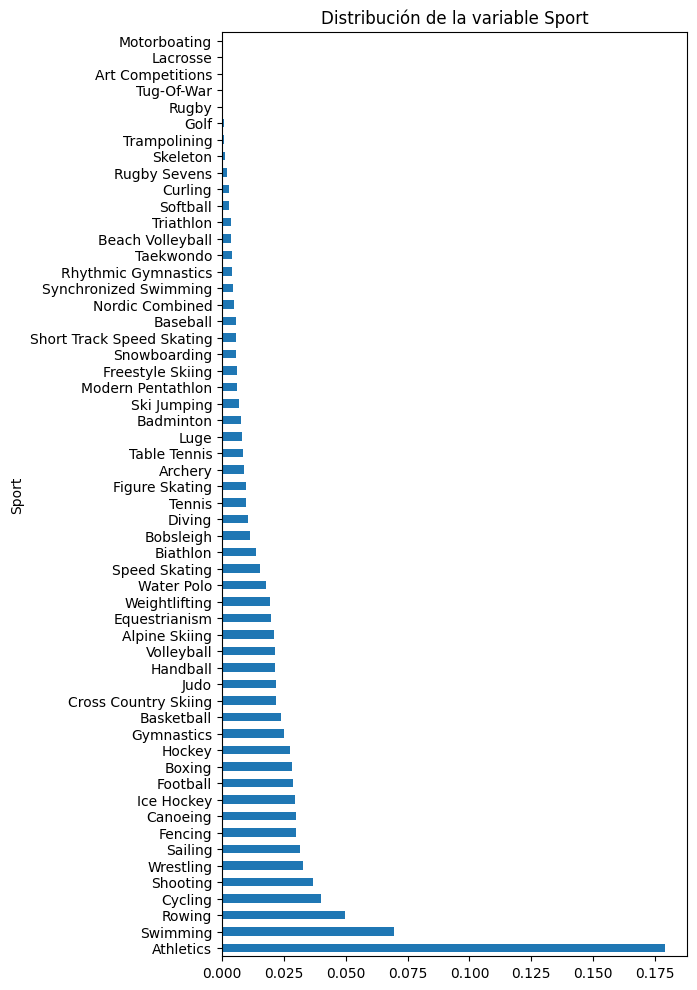

In [21]:
import matplotlib.pyplot as plt

df['Sport'].value_counts(normalize=True).plot(kind='barh', figsize=(6, 12))
plt.title('Distribución de la variable Sport')
plt.show()

In [22]:
df['Sport'].value_counts()

Sport
Athletics                    27464
Swimming                     10675
Rowing                        7647
Cycling                       6129
Shooting                      5652
Wrestling                     5025
Sailing                       4851
Fencing                       4601
Canoeing                      4560
Ice Hockey                    4546
Football                      4413
Boxing                        4362
Hockey                        4246
Gymnastics                    3816
Basketball                    3653
Cross Country Skiing          3351
Judo                          3330
Handball                      3313
Volleyball                    3266
Alpine Skiing                 3196
Equestrianism                 3059
Weightlifting                 2971
Water Polo                    2714
Speed Skating                 2338
Biathlon                      2078
Bobsleigh                     1736
Diving                        1628
Tennis                        1476
Figure Skating

**Sport** tiene 56 categorías, así que ya la considero de **alta cardinalidad**. Además, mirando el conteo, hay deportes con muchísimos registros (Athletics, Swimming) y otros con casi nada (Motorboating tiene 1 solo registro, Lacrosse 2, Art Competitions 15). Esas categorías tan pequeñas serían las **atípicas**: no creo que sean errores de digitación, más bien son deportes que casi no aparecen en los Juegos Olímpicos modernos (algunos ni siquiera se siguen jugando).

In [23]:
df['NOC'].value_counts()

NOC
USA    11196
GBR     5701
FRA     5649
GER     5625
CAN     5578
       ...  
SSD        3
YMD        2
SAA        2
UAR        1
NFL        1
Name: count, Length: 226, dtype: int64

**NOC** tiene 226 categorías, es la de más alta cardinalidad de todas las que me quedaron. También hay países con muchísimos registros (USA, GBR) y códigos con muy pocos (algunos con 1, 2 o 3 registros, casi siempre comités que ya no existen, como URS que era la Unión Soviética). Esas también las cuento como categorías atípicas por su frecuencia tan baja.

In [24]:
df['City'].value_counts()

City
London                    11539
Rio de Janeiro            11355
Beijing                   11141
Athina                    11118
Sydney                    10952
Atlanta                    9258
Seoul                      8488
Barcelona                  7797
Munich                     7094
Los Angeles                7012
Montreal                   6137
Mexico City                5711
Roma                       5250
Moskva                     5239
Tokyo                      5139
Sochi                      2859
Vancouver                  2737
Torino                     2707
Salt Lake City             2550
Nagano                     2296
Lillehammer                1787
Innsbruck                  1758
Albertville                1629
Melbourne                  1504
Helsinki                   1252
Sarajevo                   1249
Calgary                    1218
Grenoble                   1195
Sapporo                    1075
Lake Placid                 958
Berlin                      668
Ams

**City** tiene 42 categorías. No sé si 42 ya cuenta como "alta" cardinalidad, pero comparado con Sport (56) y sobre todo con NOC (226) me parece que no es tan grave. Tampoco veo categorías raras, cada ciudad sede tiene un número razonable de registros.

**Lo que encontré en esta parte:**

De las variables categóricas que me quedaron, **Medal** es la única **ordinal** (No medal < Bronze < Silver < Gold), porque hay un orden claro de logro. Todas las demás son **nominales**: **Sex** y **Season** (binarias, sin orden), **Sport** (56 categorías, alta cardinalidad, con categorías atípicas de muy baja frecuencia como Motorboating o Lacrosse), **NOC** (226 categorías, la de mayor cardinalidad, también con países/comités con muy pocos registros) y **City** (42 categorías, cardinalidad moderada, sin categorías raras que yo haya notado).

Ahora, pensando en cómo procesaría cada una:

- **Sex** y **Season**: como son binarias, las codificaría con `OneHotEncoder(drop='if_binary')`, para no crear una columna redundante.
- **Medal**: al ser ordinal, la codificaría con `OrdinalEncoder`, respetando el orden No medal < Bronze < Silver < Gold.
- **Sport** y **NOC**: son nominales pero de cardinalidad alta, así que las codificaría con `OneHotEncoder`, agrupando las categorías menos frecuentes con `min_frequency` para no terminar con decenas de columnas casi vacías.
- **City**: también nominal, la codificaría con `OneHotEncoder` normal, ya que su cardinalidad me parece más manejable.

Haga un análisis de las variables cuantitativas no descartadas, e identifique:

- Variables que son aproximadamente normales.
- Variables con datos atípicos.

Indique qué tipo de procesamiento debería recibir cada una de las variables, según su distribución y la presencia de valores atípicos.

Reporte los resultados del análisis en una celda de texto.

In [25]:
num_cols = ['Age', 'Height', 'Year']
df[num_cols].describe()

,Age,Height,Year
count,153410.000000,153410.000000,153410.000000
mean,25.471051,176.517509,1990.445955
std,5.426673,10.380797,20.128943
min,11.000000,127.000000,1896.000000
25%,22.000000,170.000000,1976.000000
50%,25.000000,176.000000,1996.000000
75%,28.000000,183.000000,2008.000000
max,71.000000,226.000000,2016.000000


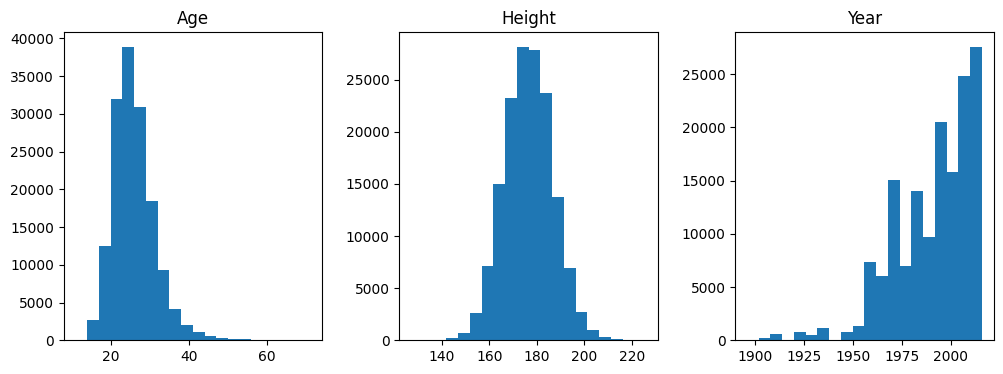

In [26]:
df[num_cols].hist(figsize=(12, 4), bins=20, layout=(1, 3), grid=False)
plt.show()

In [27]:
for c in num_cols:
    print(f'{c} -> asimetría: {df[c].skew():.2f}, curtosis: {df[c].kurt():.2f}')

Age -> asimetría: 1.18, curtosis: 3.25
Height -> asimetría: 0.07, curtosis: 0.13
Year -> asimetría: -1.01, curtosis: 1.29


Con los histogramas y las medidas de asimetría veo que **Height** es la que más se parece a una distribución normal (asimetría casi 0). **Age** está sesgada a la derecha (la mayoría de deportistas son jóvenes, pero hay una cola de deportistas mayores). **Year** está sesgada a la izquierda, aunque en realidad no creo que sea una variable "de distribución" como las otras dos, sino más bien el año en que se jugaron los Juegos Olímpicos (van de 1896 a 2016), así que su forma tiene que ver con que hay más registros en años recientes que en los primeros Juegos.

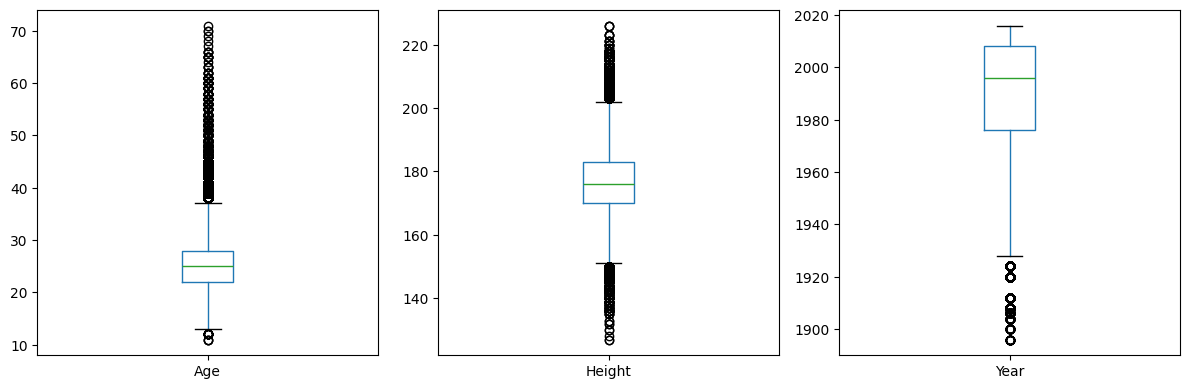

In [28]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
for i, c in enumerate(num_cols):
    df.boxplot(column=c, grid=False, ax=ax[i])
plt.tight_layout()
plt.show()

In [29]:
for c in num_cols:
    Q1 = df[c].quantile(.25)
    Q3 = df[c].quantile(.75)
    IQR = Q3 - Q1
    upper_limit = Q3 + 1.5 * IQR
    lower_limit = Q1 - 1.5 * IQR
    n_out = ((df[c] > upper_limit) | (df[c] < lower_limit)).sum()
    print(f'{c}: {n_out} posibles outliers ({n_out/df.shape[0]*100:.2f}%), rango normal [{lower_limit:.1f}, {upper_limit:.1f}]')

Age: 4499 posibles outliers (2.93%), rango normal [13.0, 37.0]
Height: 2094 posibles outliers (1.36%), rango normal [150.5, 202.5]
Year: 1729 posibles outliers (1.13%), rango normal [1928.0, 2056.0]


**Lo que encontré en esta parte:**

Viendo los histogramas, la asimetría/curtosis y los boxplots juntos, esto fue lo que saqué en claro de cada variable:

- **Height** es la variable que más se acerca a una distribución normal (asimetría de 0.07, muy poca curtosis) y tiene pocos datos atípicos (1.36% con la regla del rango intercuartílico). Por eso creo que no necesita ninguna transformación especial, tal vez solo estandarizarla con `StandardScaler` para que quede en la misma escala que las demás variables numéricas.

- **Age** no es normal: está sesgada a la derecha (asimetría 1.18) y tiene más datos atípicos (2.93%), que corresponden a deportistas bastante mayores que el resto (por ejemplo, en tiro o hípica hay competidores de más de 50 años). Como no creo que sean errores sino datos reales, no los eliminaría, pero si el modelo lo necesitara se podría aplicar alguna transformación de potencia (`PowerTransformer`) para acercarla más a la normalidad, o usar un escalador robusto (`RobustScaler`) que no se vea tan afectado por esos valores extremos.

- **Year** en realidad no me parece una variable típica para buscar outliers, porque no mide una característica del deportista sino el año de los Juegos. La "asimetría" que tiene solo refleja que hay más registros en años recientes que en los primeros Juegos Olímpicos modernos. No le haría ningún tratamiento de outliers, como mucho la estandarizaría igual que a las otras numéricas si termina entrando al modelo.

Haga análisis bivariados entre las variables de su dataset y la variable objetivo, e identifique que variables serían potencialmente buenas predictoras y cuales no.

Reporte sus resultados en una celda de texto.

In [30]:
import seaborn as sns

corr = df[['Age', 'Height', 'Weight', 'Year']].corr()
corr

,Age,Height,Weight,Year
Age,1.000000,0.086316,0.164155,0.075185
Height,0.086316,1.000000,0.775678,0.026918
Weight,0.164155,0.775678,1.000000,0.003778
Year,0.075185,0.026918,0.003778,1.000000


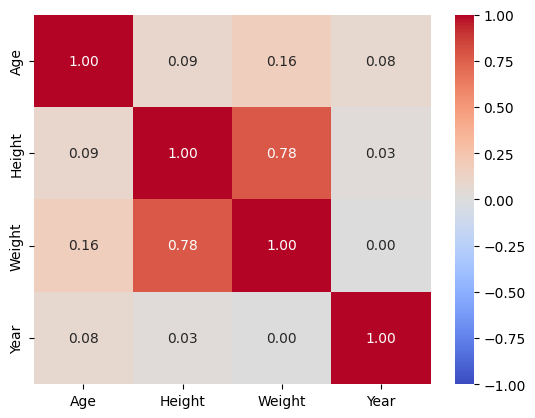

In [31]:
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.show()

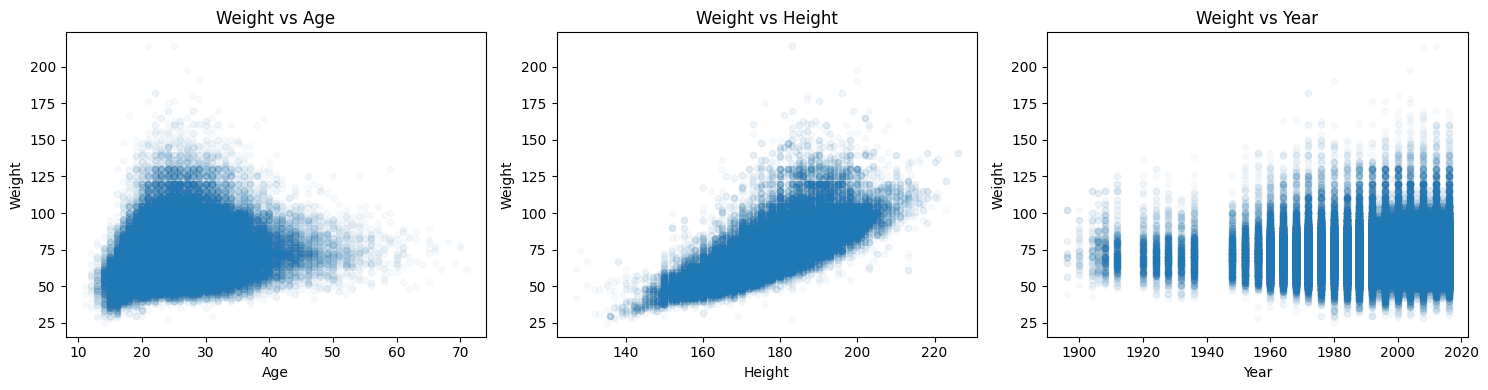

In [32]:
predictoras_num = ['Age', 'Height', 'Year']

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for i, c in enumerate(predictoras_num):
    df.plot(kind='scatter', x=c, y='Weight', alpha=0.03, ax=ax[i])
    ax[i].set_title(f'Weight vs {c}')
plt.tight_layout()
plt.show()

Hice el mismo tipo de gráfico de dispersión para las 3 (no solo para Height), para no quedarme solo con el número de la correlación y ver también la forma de cada relación.

**Height** tiene una correlación bastante alta con Weight (0.78), y se nota clarísimo en su gráfico: entre más alto es el deportista, más pesa, y la nube de puntos sube en diagonal bastante clara. Tiene mucho sentido y va a ser mi mejor variable predictora. **Age** tiene una correlación positiva pero muy débil (0.16), y en su gráfico se ve por qué: hay peso de sobra en casi todas las edades, la nube no tiene una forma tan clara como la de Height. **Year** prácticamente no tiene relación con Weight (0.004, casi cero, se ve blanquito en el mapa de calor), y su gráfico lo confirma: para cualquier año la nube de puntos cubre más o menos el mismo rango de pesos, no hay ninguna tendencia.

In [33]:
df.groupby('Sex')['Weight'].mean()

Sex
F    61.501631
M    77.105131
Name: Weight, dtype: float64

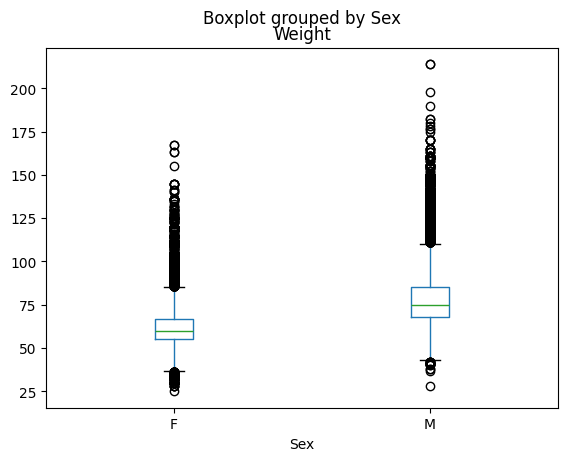

In [34]:
df.boxplot(column='Weight', by='Sex', grid=False)
plt.show()

Entre **Sex** y Weight sí hay una diferencia grande: los hombres pesan en promedio 77.1 kg y las mujeres 61.5 kg. Esta variable debería ayudar bastante al modelo.

In [35]:
df.groupby('Sport')['Weight'].mean().sort_values()

Sport
Rhythmic Gymnastics          48.760976
Gymnastics                   55.598139
Synchronized Swimming        55.741429
Trampolining                 59.322148
Figure Skating               59.533967
Diving                       60.464681
Triathlon                    61.817490
Short Track Speed Skating    64.447709
Table Tennis                 65.075486
Ski Jumping                  65.225000
Boxing                       65.313847
Cross Country Skiing         66.287228
Lacrosse                     66.500000
Freestyle Skiing             67.045705
Biathlon                     67.126564
Nordic Combined              67.468707
Softball                     67.471655
Equestrianism                67.774926
Taekwondo                    68.088087
Badminton                    68.186383
Hockey                       69.173340
Snowboarding                 69.469484
Athletics                    69.675994
Modern Pentathlon            69.902280
Archery                      69.905844
Cycling            

Con **Sport** pasa algo parecido: el promedio de peso varía muchísimo entre deportes, desde gimnasia rítmica (48.8 kg en promedio) hasta tiro de cuerda o Tug-Of-War (91.8 kg). Esto también parece una muy buena variable predictora.

In [36]:
print('Peso promedio por Medal:')
print(df.groupby('Medal')['Weight'].mean())
print()
print('Peso promedio por Season:')
print(df.groupby('Season')['Weight'].mean())
print()
print('Desviación estándar de los promedios de Weight por NOC:', df.groupby('NOC')['Weight'].mean().std().round(2))
print('Desviación estándar de los promedios de Weight por City:', df.groupby('City')['Weight'].mean().std().round(2))

Peso promedio por Medal:
Medal
Bronze      73.648694
Gold        74.567282
No medal    71.909668
Silver      73.860556
Name: Weight, dtype: float64

Peso promedio por Season:
Season
Summer    72.343408
Winter    72.088441
Name: Weight, dtype: float64

Desviación estándar de los promedios de Weight por NOC: 6.26
Desviación estándar de los promedios de Weight por City: 1.11


**Lo que encontré en esta parte:**

Juntando todo lo que fui viendo en esta sección, las variables que parecen ser **buenas predictoras** de Weight son:

- **Height**: correlación de 0.78 con Weight, es por mucho la relación más fuerte que encontré.
- **Sex**: diferencia grande entre hombres (77.1 kg) y mujeres (61.5 kg).
- **Sport**: los promedios de peso cambian muchísimo de un deporte a otro (de 48.8 kg a 91.8 kg).
- **Age**: correlación positiva pero débil (0.16), así que ayuda un poco, aunque no es de las más fuertes.
- **NOC**: los promedios por país varían con una desviación estándar de casi 6.3 kg entre países (van desde promedios de 54.7 kg hasta 98.1 kg), así que parece aportar algo, aunque sospecho que esto se debe en parte a qué deportes practica más cada país y no tanto al país en sí.

En cambio, estas variables **no parecen ser buenas predictoras**:

- **Year**: correlación prácticamente nula (0.004) con Weight.
- **Season**: los promedios de peso en Summer (72.3 kg) y Winter (72.1 kg) son casi idénticos.
- **City**: los promedios por ciudad casi no varían (desviación estándar de apenas 1.1 kg), tiene sentido porque la ciudad sede no debería tener relación con el peso de un deportista.
- **Medal**: aunque hay una pequeña diferencia (71.9 kg sin medalla vs 74.6 kg con oro), es una diferencia muy chiquita comparada con la variación normal del peso (desviación estándar de casi 15 kg), así que su aporte real probablemente sea muy bajo.

Con esto ya tengo una idea bastante clara de qué variables usar para armar el primer modelo: Height, Sex y Sport se ven como las más fuertes, y Age y NOC como un apoyo extra, aunque no muy grande.

## Procesamiento de las características y entrenamiento del modelo

Cree el matriz de características $X$ con todos las variables no descartadas de su dataframe, menos la variable **Weight**, que será su variable objetivo $y$.

Particione los datos en subconjuntos de entrenamiento y prueba, en un relacion 80/20, usando `random_state=1`.

Para una primera versión de su modelo, seleccione 5 características a procesar que, de acuerdo con el análisis exploratorio realizado, parezcan ser buenas predictoras. Dentro de las 5 debe haber al menos una característica ordinal y dos nominales.

Empaquete las transformaciones que aplicará a estas características usando `ColumnTransformer`. Use el parámetro `remainder='drop'`para descartar las variables que no va a procesar.

Para el modelado va a usar un modelo de regresión logística. Cree un flujo de trabajo que integre el procesamiento y el modelado usando `Pipeline`.

Entrene el modelo y reporte los scores de entrenamiento y de prueba.

Reporte las características con las que **realmente** fue entrenado el modelo, es decir, las resultantes del paso de procesamiento.

**Sobre el modelo a usar:** el enunciado dice que hay que tener en cuenta que Weight es una variable numérica/cuantitativa para escoger el modelo, pero más abajo pide literalmente "un modelo de regresión logística". Repasando mis apuntes y lo que vimos en el notebook de flujo de trabajo, la regresión logística es en realidad un modelo de **clasificación** (sirve para predecir categorías, no números continuos como el peso). Por eso entiendo que debe ser un error de digitación en el enunciado, y que el modelo que sí corresponde para este caso es una **regresión lineal** (`LinearRegression`), porque Weight es numérica continua. Es la que voy a usar en todo este trabajo; si no era lo que se pedía, quedo atento a la corrección.

Para elegir las 5 características, me baso en el análisis bivariado de la sección anterior: elijo **Height** y **Age** (numéricas, las dos con relación positiva con Weight), **Sex** y **Sport** (nominales, ambas con diferencias grandes de peso entre categorías) y **Medal** (la única variable ordinal que tengo disponible; en el análisis bivariado no pareció ser muy buena predictora, pero la incluyo porque el enunciado pide que haya al menos una ordinal entre las 5). Así cumplo con las condiciones de al menos 1 ordinal y 2 nominales.

In [37]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Weight'])
y = df['Weight']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1, train_size=0.8)

print('Tamaño del conjunto de entrenamiento:', X_train.shape)
print('Tamaño del conjunto de prueba:', X_test.shape)

Tamaño del conjunto de entrenamiento: (122728, 9)
Tamaño del conjunto de prueba: (30682, 9)


La primera vez que armé el `ColumnTransformer` para **Sport** con `OneHotEncoder` normal, el modelo se demoraba mucho y quedaba con demasiadas columnas (más de 50 categorías distintas), así que usé `min_frequency` para agrupar las categorías menos frecuentes en una sola, tal como se hizo en el notebook de variables categóricas con la columna native-country.

In [38]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

orden_medal = ['No medal', 'Bronze', 'Silver', 'Gold']

preprocessor = ColumnTransformer(transformers=[
    ('numericas', StandardScaler(), ['Height', 'Age']),
    ('sex', OneHotEncoder(drop='if_binary', sparse_output=False), ['Sex']),
    ('sport', OneHotEncoder(sparse_output=False, handle_unknown='ignore', min_frequency=2000), ['Sport']),
    ('medal', OrdinalEncoder(categories=[orden_medal], dtype='int'), ['Medal']),
    ],
    remainder='drop')

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numericas', ...), ('sex', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_nam

Nota: le agregué `handle_unknown='ignore'` al `OneHotEncoder` de Sport porque sin ese parámetro me tiraba un error al evaluar en el conjunto de prueba (`ValueError`, por una categoría que el codificador no había visto en entrenamiento, cosa que tiene sentido porque hay deportes con muy pocos registros y algunos quedaron solo en el conjunto de prueba). Ese parámetro no lo vimos en clase, pero busqué en la documentación de `OneHotEncoder` de sklearn y con `handle_unknown='ignore'` esas categorías nuevas simplemente quedan en ceros en vez de tumbar el código, así que lo dejé así para que el modelo pudiera evaluarse sin problema.

In [39]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
    ])

pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numericas', ...), ('sex', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tran

In [40]:
print('R2 en entrenamiento:', pipeline.score(X_train, y_train))
print('R2 en prueba:', pipeline.score(X_test, y_test))

R2 en entrenamiento: 0.6884306786121847
R2 en prueba: 0.6833648075335825


Los dos scores están bastante parecidos (0.688 en entrenamiento y 0.683 en prueba), así que no parece que el modelo esté sobreajustado. Un R² de casi 0.69 significa que el modelo logra explicar cerca del 69% de la variabilidad del peso con solo estas 5 características, lo cual me parece bastante bien para un modelo lineal tan simple.

In [41]:
features = pipeline.named_steps['preprocessor'].get_feature_names_out()
print('Número de características con las que realmente se entrenó el modelo:', len(features))
features

Número de características con las que realmente se entrenó el modelo: 28


array(['numericas__Height', 'numericas__Age', 'sex__Sex_M',
       'sport__Sport_Alpine Skiing', 'sport__Sport_Athletics',
       'sport__Sport_Basketball', 'sport__Sport_Boxing',
       'sport__Sport_Canoeing', 'sport__Sport_Cross Country Skiing',
       'sport__Sport_Cycling', 'sport__Sport_Equestrianism',
       'sport__Sport_Fencing', 'sport__Sport_Football',
       'sport__Sport_Gymnastics', 'sport__Sport_Handball',
       'sport__Sport_Hockey', 'sport__Sport_Ice Hockey',
       'sport__Sport_Judo', 'sport__Sport_Rowing', 'sport__Sport_Sailing',
       'sport__Sport_Shooting', 'sport__Sport_Swimming',
       'sport__Sport_Volleyball', 'sport__Sport_Water Polo',
       'sport__Sport_Weightlifting', 'sport__Sport_Wrestling',
       'sport__Sport_infrequent_sklearn', 'medal__Medal'], dtype=object)

Aunque solo elegí 5 columnas originales, el modelo terminó entrenándose con 28 características. Esto pasa porque `OneHotEncoder` convierte cada categoría de **Sport** en su propia columna (0/1), y como agrupé las categorías poco frecuentes con `min_frequency=2000`, quedaron 23 categorías de deporte más una columna "infrequent" para las que agrupé, además de Height, Age, Sex y Medal.

Vuelva a entrenar el modelo, pero esta vez añada 2 características adicionales.

Reporte los scores de entrenamiento y de prueba del modelo reentrenado.

Reporte las características con las que **realmente** fue reentrenado el modelo, es decir, las resultantes del paso de procesamiento.

Para esta segunda versión añado **NOC** y **Year**. Escogí NOC porque en el análisis bivariado fue la variable que más variación mostró entre grupos después de Sex y Sport (desviación estándar de casi 6.3 kg entre países). Year lo agrego más que todo para comprobar si de verdad no aporta nada, ya que en el análisis bivariado su correlación con Weight fue prácticamente 0; tenía curiosidad de verlo confirmado en un modelo real y no solo en la correlación.

In [42]:
preprocessor_v2 = ColumnTransformer(transformers=[
    ('numericas', StandardScaler(), ['Height', 'Age', 'Year']),
    ('sex', OneHotEncoder(drop='if_binary', sparse_output=False), ['Sex']),
    ('sport', OneHotEncoder(sparse_output=False, handle_unknown='ignore', min_frequency=2000), ['Sport']),
    ('noc', OneHotEncoder(sparse_output=False, handle_unknown='ignore', min_frequency=1500), ['NOC']),
    ('medal', OrdinalEncoder(categories=[orden_medal], dtype='int'), ['Medal']),
    ],
    remainder='drop')

pipeline_v2 = Pipeline(steps=[
    ('preprocessor', preprocessor_v2),
    ('model', LinearRegression())
    ])

pipeline_v2.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numericas', ...), ('sex', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tran

In [43]:
print('R2 en entrenamiento (modelo 2):', pipeline_v2.score(X_train, y_train))
print('R2 en prueba (modelo 2):', pipeline_v2.score(X_test, y_test))

R2 en entrenamiento (modelo 2): 0.6899779625891331
R2 en prueba (modelo 2): 0.6846601830896941


In [44]:
features_v2 = pipeline_v2.named_steps['preprocessor'].get_feature_names_out()
print('Número de características con las que realmente se entrenó el modelo 2:', len(features_v2))
features_v2

Número de características con las que realmente se entrenó el modelo 2: 55


array(['numericas__Height', 'numericas__Age', 'numericas__Year',
       'sex__Sex_M', 'sport__Sport_Alpine Skiing',
       'sport__Sport_Athletics', 'sport__Sport_Basketball',
       'sport__Sport_Boxing', 'sport__Sport_Canoeing',
       'sport__Sport_Cross Country Skiing', 'sport__Sport_Cycling',
       'sport__Sport_Equestrianism', 'sport__Sport_Fencing',
       'sport__Sport_Football', 'sport__Sport_Gymnastics',
       'sport__Sport_Handball', 'sport__Sport_Hockey',
       'sport__Sport_Ice Hockey', 'sport__Sport_Judo',
       'sport__Sport_Rowing', 'sport__Sport_Sailing',
       'sport__Sport_Shooting', 'sport__Sport_Swimming',
       'sport__Sport_Volleyball', 'sport__Sport_Water Polo',
       'sport__Sport_Weightlifting', 'sport__Sport_Wrestling',
       'sport__Sport_infrequent_sklearn', 'noc__NOC_AUS', 'noc__NOC_AUT',
       'noc__NOC_BRA', 'noc__NOC_CAN', 'noc__NOC_CHN', 'noc__NOC_ESP',
       'noc__NOC_FIN', 'noc__NOC_FRA', 'noc__NOC_FRG', 'noc__NOC_GBR',
       'noc__NOC_GDR

**Comparación de los 2 modelos:**

El modelo 1 (Height, Age, Sex, Sport y Medal, que terminaron siendo 28 columnas después de procesarlas) dio un R² de 0.6884 en entrenamiento y 0.6834 en prueba. El modelo 2, agregando NOC y Year (55 columnas procesadas en total), subió apenas a 0.6900 en entrenamiento y 0.6847 en prueba.

O sea que agregar esas 2 variables sí mejoró un poquito el modelo, pero la mejora es muy chiquita, casi no se nota (menos de 0.002 en el R² de prueba). Esto coincide con lo que había visto en el análisis bivariado: como Year prácticamente no tenía relación con Weight, me imagino que casi toda esa mejora tan pequeña viene de NOC y no de Year. Con este ejercicio entendí que agregar más variables no siempre mejora mucho un modelo, sobre todo si esas variables ya no tenían tanta relación con lo que se quiere predecir desde el análisis exploratorio; las que de verdad marcaron la diferencia fueron Height, Sex y Sport, que fueron justo las que el análisis exploratorio había señalado como las más prometedoras desde el principio.